In [44]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

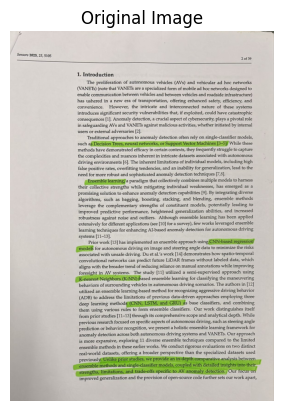

In [45]:
image = cv2.imread("../data/sample1.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

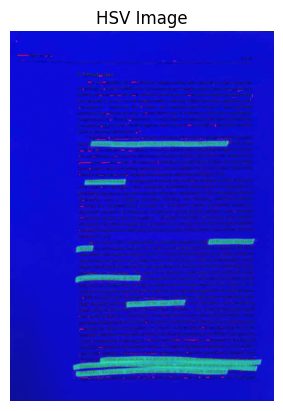

In [46]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
plt.imshow(image_hsv)
plt.title("HSV Image")
plt.axis('off')
plt.show()

HSV IMAGE SHAPE: (1600, 1142, 3)
HSV IMAGE WITH ONLY THE SATURATION LAYER: (1600, 1142)


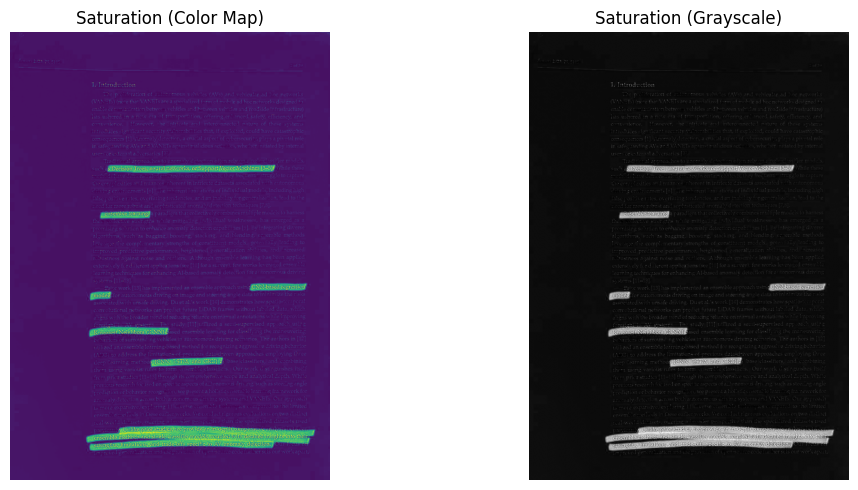

In [47]:
print("HSV IMAGE SHAPE:",image_hsv.shape)
image_sat = image_hsv[:,:,1]
print("HSV IMAGE WITH ONLY THE SATURATION LAYER:",image_sat.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_sat)
plt.title('Saturation (Color Map)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_sat, cmap='gray')
plt.title('Saturation (Grayscale)')
plt.axis('off')

plt.tight_layout()
plt.show()

## using threshold directly to create the mask

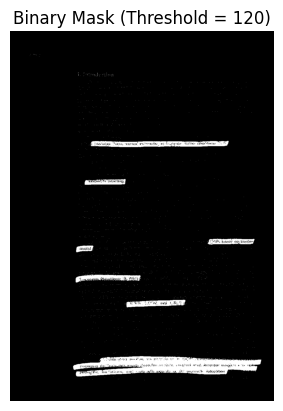

In [48]:
threshold = 120

# method 1
'''  
rows, columns = image_sat.shape
image_binary = image_sat.copy()

for i in range(rows):
    for j in range(columns):
        if image_sat[i, j] > threshold:
            image_binary[i, j] = 255
        else:
            image_binary[i, j] = 0


'''
# method 2
image_binary = (image_sat > threshold).astype(np.uint8) * 255


plt.imshow(image_binary, cmap='gray')
plt.title(f'Binary Mask (Threshold = {threshold})')
plt.axis('off')
plt.show()

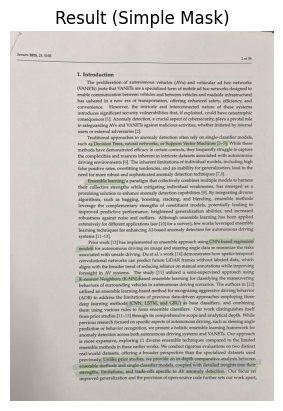

In [49]:
image_hsv_new = image_hsv.copy()

'''
for i in range(rows):
    for j in range(columns):
        if image_binary[i, j] == 255:
            image_hsv_new[i, j, 1] = 0
'''
image_hsv_new[image_binary == 255, 1] = 0
image_final = cv2.cvtColor(image_hsv_new, cv2.COLOR_HSV2RGB)
cv2.imwrite('../data/result_simple_mask.jpg', cv2.cvtColor(image_final, cv2.COLOR_RGB2BGR))
plt.imshow(image_final)
plt.title('Result (Simple Mask)')
plt.axis('off')
plt.show()

## Apply Gaussian blur, then threshold, then dilate for a better mask

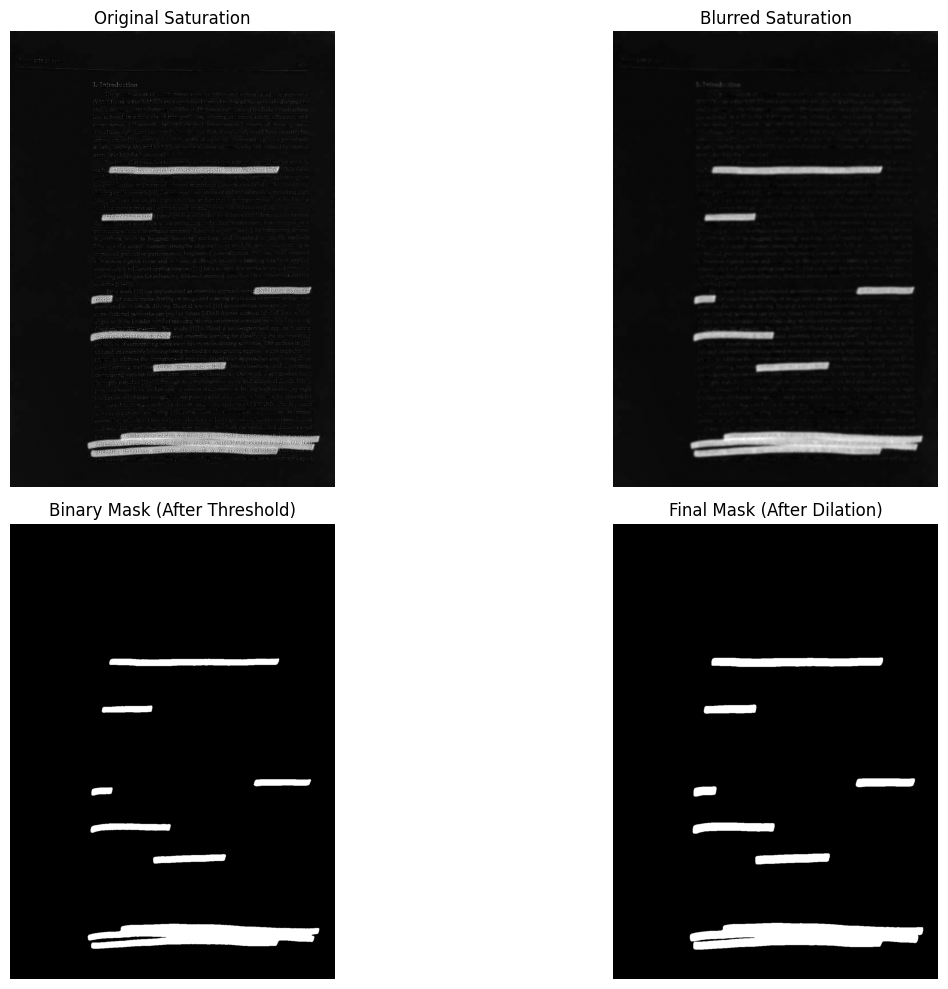

In [50]:
#blur
image_sat_blur = cv2.GaussianBlur(image_sat, (15, 15), 0)

#threshold
threshold = 100
image_binary = (image_sat_blur > threshold).astype(np.uint8) * 255

#dialation
kernel = np.ones((7, 7), np.uint8)
image_binary_dilated = cv2.dilate(image_binary, kernel, iterations=1)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(image_sat, cmap='gray')
plt.title('Original Saturation')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(image_sat_blur, cmap='gray')
plt.title('Blurred Saturation')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(image_binary, cmap='gray')
plt.title('Binary Mask (After Threshold)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(image_binary_dilated, cmap='gray')
plt.title('Final Mask (After Dilation)')
plt.axis('off')

plt.tight_layout()
plt.show()

image_binary = image_binary_dilated

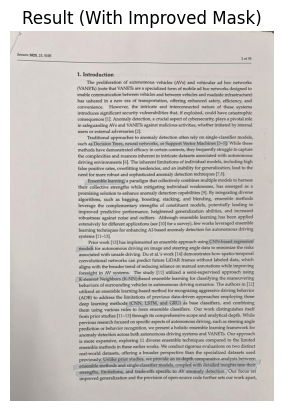

In [51]:
image_hsv_new = image_hsv.copy()

'''
for i in range(rows):
    for j in range(columns):
        if image_binary[i, j] == 255:
            image_hsv_new[i, j, 1] = 0
'''
image_hsv_new[image_binary == 255, 1] = 0
image_final = cv2.cvtColor(image_hsv_new, cv2.COLOR_HSV2RGB)

cv2.imwrite('../data/result_better_mask.jpg', cv2.cvtColor(image_final, cv2.COLOR_RGB2BGR))
plt.imshow(image_final)
plt.title('Result (With Improved Mask)')
plt.axis('off')
plt.show()

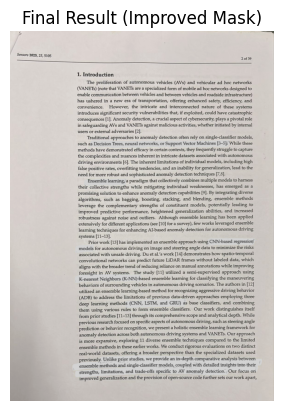

In [53]:
image_hsv_new = image_hsv.copy()
image_hsv_new[image_binary == 255, 1] = 0

# getting the high value pixels from the non highlighted areas (assuming them to be the white paper background)
non_highlighted_paper = image_hsv[(image_binary == 0) & (image_hsv[:,:,2] > 150), 2]
actual_paper_brightness = np.median(non_highlighted_paper)


# highlighted areas (excluding the actual text on the paper)
bright_mask = (image_binary == 255) & (image_hsv[:,:,2] > 160)
image_hsv_new[bright_mask, 2] = actual_paper_brightness

image_final = cv2.cvtColor(image_hsv_new, cv2.COLOR_HSV2RGB)
cv2.imwrite('../data/result_final.jpg', cv2.cvtColor(image_final, cv2.COLOR_RGB2BGR))
plt.imshow(image_final)
plt.title('Final Result (Improved Mask)')
plt.axis('off')
plt.show()
